# Modelling
## Customer Segmentation using the UCI Online Retail Dataset

**CRISP-DM phase:** Modelling
**Author:** Godwin — Machine Learning Engineer
**Objective:** Engineer RFM (Recency, Frequency, Monetary) features at the customer level from Ibrahim's cleaned transaction data, scale/transform them appropriately for clustering, compare K-Means, Hierarchical, and DBSCAN, choose a final segmentation, and assign every customer to a segment.

 The EDA already showed that:
- Recency, Frequency, and Monetary are all heavily right-skewed, so log transformation is needed before clustering.
- A small number of customers (e.g. wholesale-style buyers) sit far out in the tails and can pull K-Means centroids if left untreated.
- The client has explicitly said the **number of clusters is secondary to whether the clusters mean something for the business** — so model selection here is guided by both statistical fit (elbow, silhouette) and interpretability, not silhouette score alone.


## 1. Setup

In [1]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import skew
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = Path("../data/processed/online_retail_clean.csv")
FIGURES_DIR = Path("../figures")
MODELS_DIR = Path("../models")
PROCESSED_DIR = Path("../data/processed")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [2]:
df = pd.read_csv(DATA_PATH)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)

print(f"Rows: {df.shape[0]:,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
df.head()

Rows: 392,692
Unique customers: 4,338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 2. Rebuild the modelling-ready transaction set

The EDA notebook excluded non-product stock codes (postage, manual adjustments, bank charges, etc.) before doing any customer-level analysis, since these rows aren't real purchases and would distort RFM. I'm repeating that same filter here so this notebook produces the same transaction base the EDA insights were drawn from.

In [3]:
non_product_codes = ["POST", "M", "D", "DOT", "C2", "BANK CHARGES", "PADS", "CRUK"]
df_model = df[~df["StockCode"].isin(non_product_codes)].copy()

print(f"Rows before non-product filtering: {df.shape[0]:,}")
print(f"Rows after non-product filtering:  {df_model.shape[0]:,}")
print(f"Customers retained: {df_model['CustomerID'].nunique():,}")

Rows before non-product filtering: 392,692
Rows after non-product filtering:  391,150
Customers retained: 4,334


## 3. RFM feature engineering

Building the three core features at customer level, using the same definitions previewed in the EDA:

- **Recency** — days between the customer's last purchase and one day after the most recent invoice in the dataset (the "analysis date").
- **Frequency** — number of distinct invoices (orders) placed.
- **Monetary** — total revenue (`TotalPrice`) generated by the customer.

In [4]:
analysis_date = df_model["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Analysis date: {analysis_date.date()}")

rfm = (
    df_model.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalPrice", "sum"),
    )
    .reset_index()
)

print(f"Customers with an RFM profile: {rfm.shape[0]:,}")
rfm.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

Analysis date: 2011-12-10
Customers with an RFM profile: 4,334


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Recency,"4,334.00",92.70,100.18,1.00,1.00,3.00,18.00,51.00,143.00,312.00,369.00,374.00
Frequency,"4,334.00",4.25,7.63,1.00,1.00,1.00,1.00,2.00,5.00,13.00,30.00,206.00
Monetary,"4,334.00","2,015.97","8,903.67",3.75,52.20,110.96,304.24,662.57,"1,631.62","5,735.22","18,715.31","279,138.02"


Quick sanity check: no customer should have zero or negative Monetary value once refunds/cancellations were removed upstream by Ibrahim.

In [5]:
print("Customers with Monetary <= 0:", (rfm["Monetary"] <= 0).sum())
print("Customers with Frequency <= 0:", (rfm["Frequency"] <= 0).sum())

Customers with Monetary <= 0: 0
Customers with Frequency <= 0: 0


## 4. Checking skew before transforming

The EDA flagged Frequency and Monetary as extremely right-skewed (a handful of high-volume/wholesale-style customers dominate the tail). K-Means and hierarchical clustering both rely on Euclidean distance, so if I feed in raw RFM values, Monetary alone would dominate the distance calculation and the clusters would basically just be "who spent a lot of money" rather than a genuine blend of recency, frequency, and monetary behavior.

Recency    skew: 1.24
Frequency  skew: 11.95
Monetary   skew: 19.57


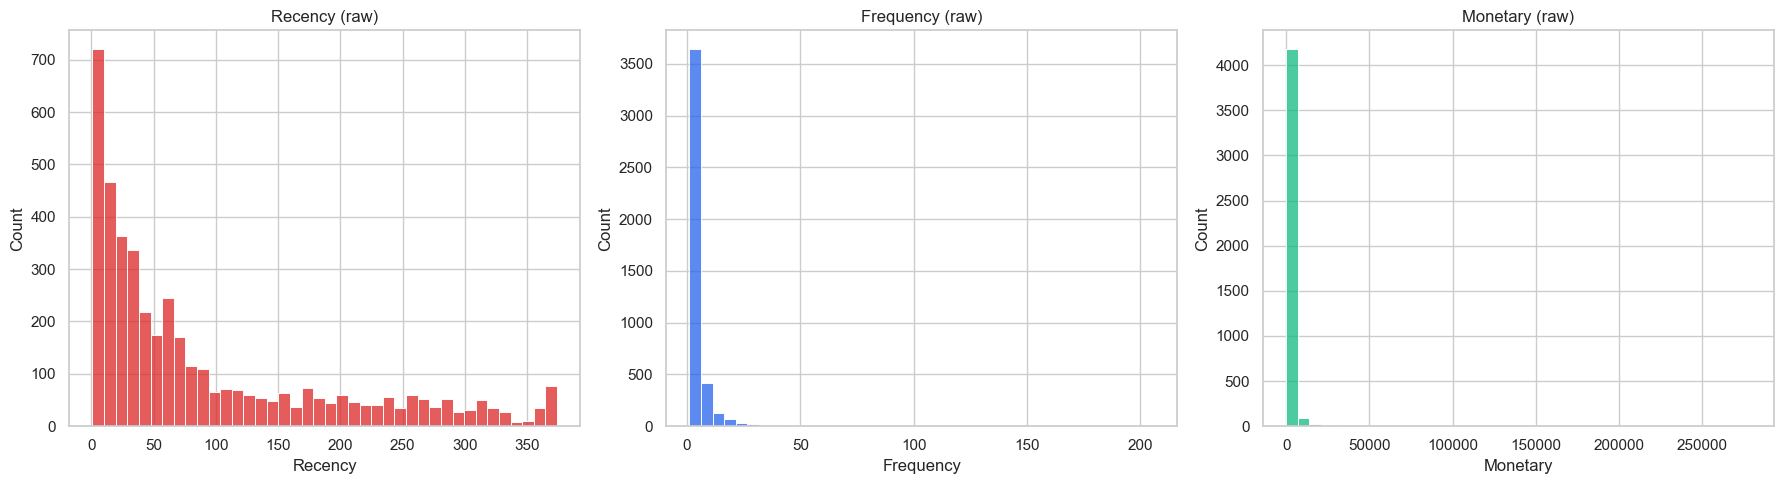

In [6]:
for col in ["Recency", "Frequency", "Monetary"]:
    print(f"{col:<10} skew: {skew(rfm[col]):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm["Recency"], bins=40, ax=axes[0], color="#DC2626")
axes[0].set_title("Recency (raw)")
sns.histplot(rfm["Frequency"], bins=40, ax=axes[1], color="#2563EB")
axes[1].set_title("Frequency (raw)")
sns.histplot(rfm["Monetary"], bins=40, ax=axes[2], color="#10B981")
axes[2].set_title("Monetary (raw)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rfm_raw_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Log transformation

Applying `log1p` to all three features. This isn't just for Frequency and Monetary — Recency also has a positive skew (a long tail of lapsed customers), and treating all three features consistently keeps the scaling step honest. `log1p` is used instead of a plain `log` because Recency, Frequency, and (rarely) Monetary can be very small or effectively hit the lower bound, and `log1p` handles that gracefully.

Recency_log     skew: -0.38
Frequency_log   skew: 1.21
Monetary_log    skew: 0.40


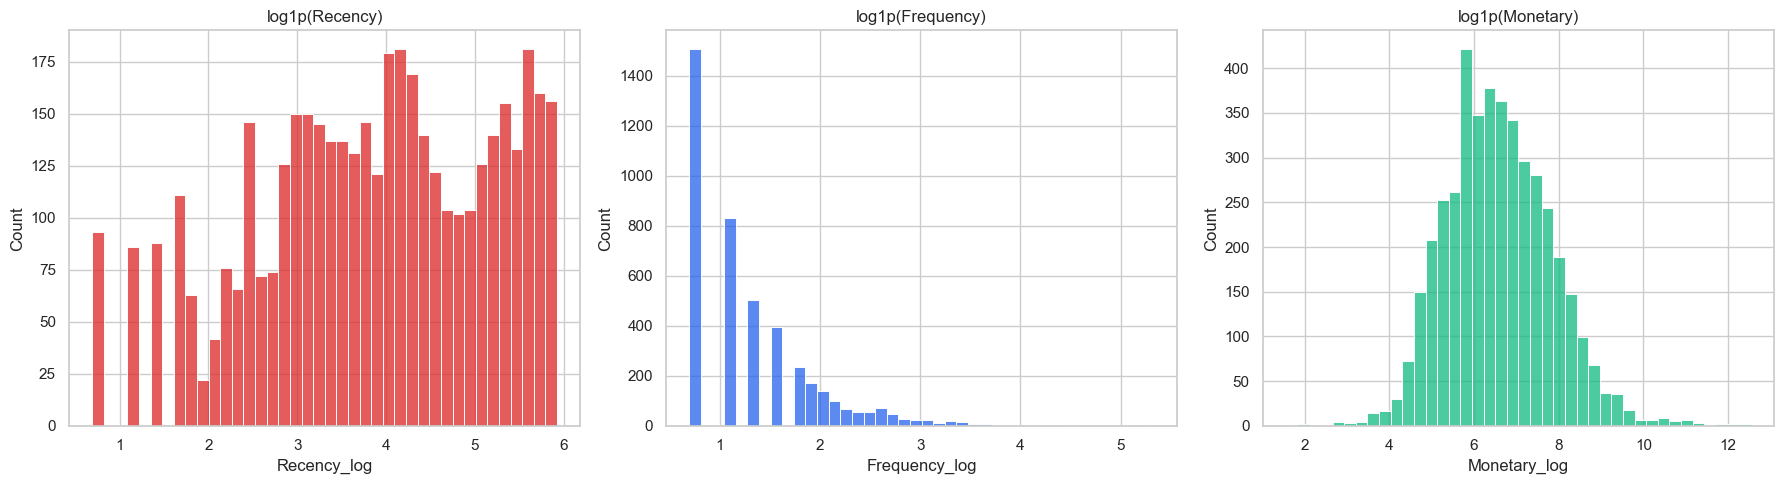

In [7]:
rfm["Recency_log"] = np.log1p(rfm["Recency"])
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])

for col in ["Recency_log", "Frequency_log", "Monetary_log"]:
    print(f"{col:<15} skew: {skew(rfm[col]):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm["Recency_log"], bins=40, ax=axes[0], color="#DC2626")
axes[0].set_title("log1p(Recency)")
sns.histplot(rfm["Frequency_log"], bins=40, ax=axes[1], color="#2563EB")
axes[1].set_title("log1p(Frequency)")
sns.histplot(rfm["Monetary_log"], bins=40, ax=axes[2], color="#10B981")
axes[2].set_title("log1p(Monetary)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rfm_log_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

The log transform pulls all three skew values much closer to zero (Monetary drops from ~19.6 to under 0.5). This is a much more clustering-friendly shape.

## 6. Handling extreme outliers

Even after the log transform, a small number of customers sit well outside the normal range on one or more features — these are the wholesale-style buyers the EDA already flagged (e.g. `CustomerID 15749`). Left in, they can pull K-Means centroids toward themselves and produce a "everyone vs. the whale" split that isn't useful for marketing segmentation.

I'm flagging these using the standard 1.5×IQR rule on the **log-transformed** features. They're excluded from *fitting* the clustering model, but not thrown away — every one of them gets assigned to a dedicated "Outlier / Wholesale" segment later so the final deliverable still covers 100% of customers.

In [8]:
def iqr_bounds(series):
    q1, q3 = np.percentile(series, [25, 75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_flags = pd.DataFrame(index=rfm.index)
for col in ["Recency_log", "Frequency_log", "Monetary_log"]:
    lower, upper = iqr_bounds(rfm[col])
    outlier_flags[col] = (rfm[col] < lower) | (rfm[col] > upper)
    print(f"{col:<15} bounds: [{lower:.2f}, {upper:.2f}]  -> {outlier_flags[col].sum()} flagged")

rfm["is_outlier"] = outlier_flags.any(axis=1)
print(f"\nTotal customers flagged as outliers: {rfm['is_outlier'].sum()} "
      f"({rfm['is_outlier'].mean() * 100:.1f}% of {len(rfm):,})")

Recency_log     bounds: [-0.09, 8.01]  -> 0 flagged
Frequency_log   bounds: [-0.95, 3.44]  -> 42 flagged
Monetary_log    bounds: [3.21, 9.91]  -> 53 flagged

Total customers flagged as outliers: 73 (1.7% of 4,334)


## 7. Scaling

Fitting `StandardScaler` on the log-transformed features of the **core** (non-outlier) customers only, so the outliers can't distort the mean/variance used for scaling. The fitted scaler is then reused to transform the outlier customers too, so everything stays on the same scale downstream.

In [9]:
feature_cols = ["Recency_log", "Frequency_log", "Monetary_log"]

core = rfm.loc[~rfm["is_outlier"]].copy()
outliers = rfm.loc[rfm["is_outlier"]].copy()

scaler = StandardScaler()
X_core_scaled = scaler.fit_transform(core[feature_cols])

print(f"Core customers used for model fitting: {core.shape[0]:,}")
print(f"Outlier customers set aside:            {outliers.shape[0]:,}")
print(f"Feature matrix shape: {X_core_scaled.shape}")

Core customers used for model fitting: 4,261
Outlier customers set aside:            73
Feature matrix shape: (4261, 3)


## 8. Clustering approach 1 — K-Means

Sweeping `k` from 2 to 10 and tracking both inertia (for the elbow method) and silhouette score, plus Davies-Bouldin as a secondary check.

In [11]:
k_range = range(2, 11)
inertias, silhouettes, db_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_core_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_core_scaled, labels))
    db_scores.append(davies_bouldin_score(X_core_scaled, labels))

kmeans_results = pd.DataFrame({
    "k": list(k_range),
    "inertia": inertias,
    "silhouette": silhouettes,
    "davies_bouldin": db_scores,
})
kmeans_results

,k,inertia,silhouette,davies_bouldin
0,2,"6,206.12",0.43,0.89
1,3,"4,699.17",0.33,1.09
2,4,"3,740.26",0.33,1.02
3,5,"3,158.03",0.32,1.02
4,6,"2,705.25",0.31,1.00
5,7,"2,450.45",0.31,0.99
6,8,"2,243.55",0.30,1.01
7,9,"2,064.52",0.28,1.03
8,10,"1,915.45",0.28,1.03


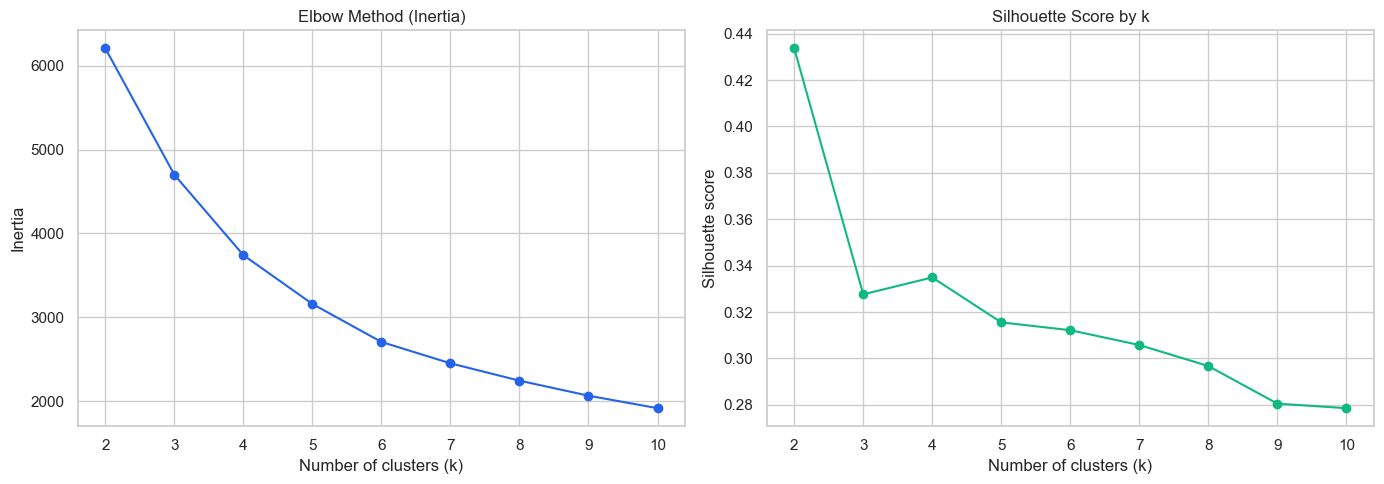

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(kmeans_results["k"], kmeans_results["inertia"], marker="o", color="#2563EB")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o", color="#10B981")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

Silhouette is technically highest at k=2, which makes sense statistically — the biggest gap in the data is simply "active vs. inactive" customers. But a 2-segment view isn't useful for a marketing team that needs to design different campaigns for different customer types. There's a second, more actionable elbow around **k=4**: inertia's rate of improvement flattens out noticeably after this point, and silhouette is still reasonable (~0.33) — comparable to the drop-off between k=2 and k=3, but with far more business-usable granularity.

Per the client's note that cluster *meaning* matters more than the raw cluster count, I'll carry k=4 forward as the candidate for K-Means and confirm it against the other two algorithms before finalizing.

## 9. Clustering approach 2 — Hierarchical (Agglomerative) Clustering

Using Ward linkage (minimizes within-cluster variance, the closest hierarchical analogue to K-Means) and comparing the same range of k via silhouette score. A dendrogram on a random sample of customers is used to visualize the merge structure — plotting all 4,000+ customers directly is unreadable.

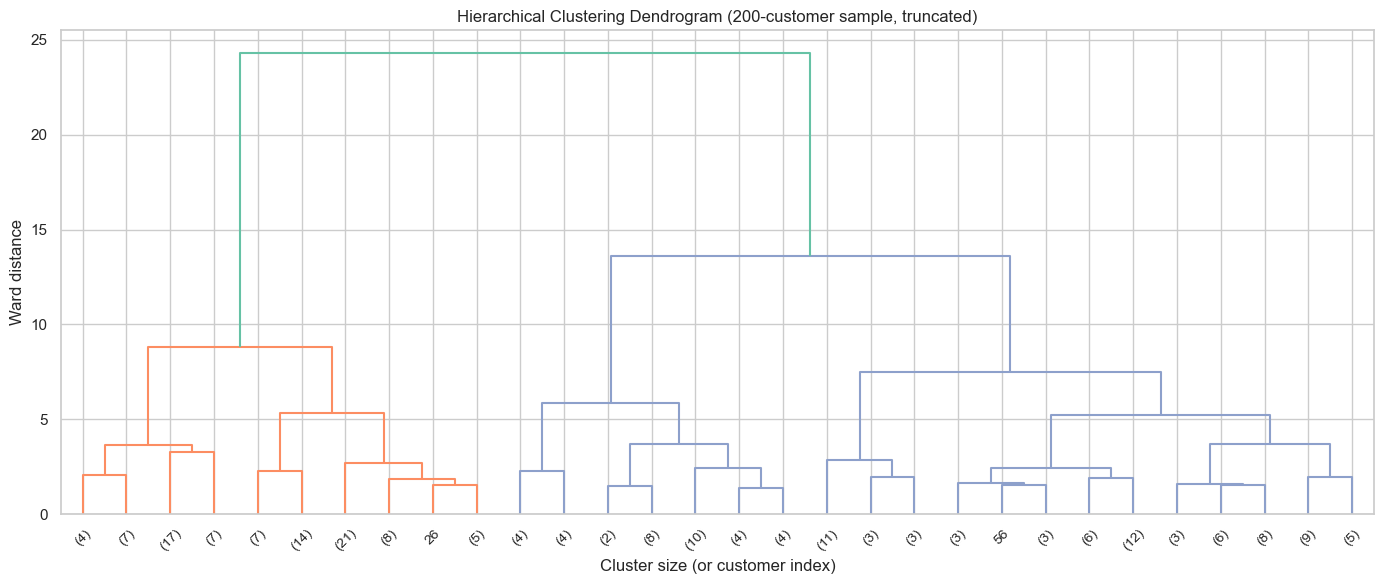

In [13]:
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(X_core_scaled.shape[0], size=min(200, X_core_scaled.shape[0]), replace=False)
X_sample = X_core_scaled[sample_idx]

linked = linkage(X_sample, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.title("Hierarchical Clustering Dendrogram (200-customer sample, truncated)")
plt.xlabel("Cluster size (or customer index)")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "hierarchical_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
agglo_results = []
for k in range(2, 11):
    agglo = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agglo.fit_predict(X_core_scaled)
    agglo_results.append({
        "k": k,
        "silhouette": silhouette_score(X_core_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_core_scaled, labels),
    })

agglo_results = pd.DataFrame(agglo_results)
agglo_results

,k,silhouette,davies_bouldin
0,2,0.39,0.95
1,3,0.33,1.01
2,4,0.30,1.15
3,5,0.23,1.25
4,6,0.23,1.14
5,7,0.22,1.14
6,8,0.23,1.19
7,9,0.21,1.22
8,10,0.21,1.23


Hierarchical clustering tells a very similar story to K-Means: silhouette is best at low k and degrades as k grows, with k=3–4 being the most defensible "elbow" for interpretability. The dendrogram itself shows a fairly clean split into ~3-4 major branches before merges start happening at much larger distances, which lines up with the silhouette numbers.

## 10. Clustering approach 3 — DBSCAN

DBSCAN doesn't need a predefined number of clusters, but it does need `eps` (neighborhood radius) and `min_samples`. I'm using a k-distance plot (5th nearest neighbor distance, sorted) to estimate a reasonable `eps`, then sweeping a few candidate values.

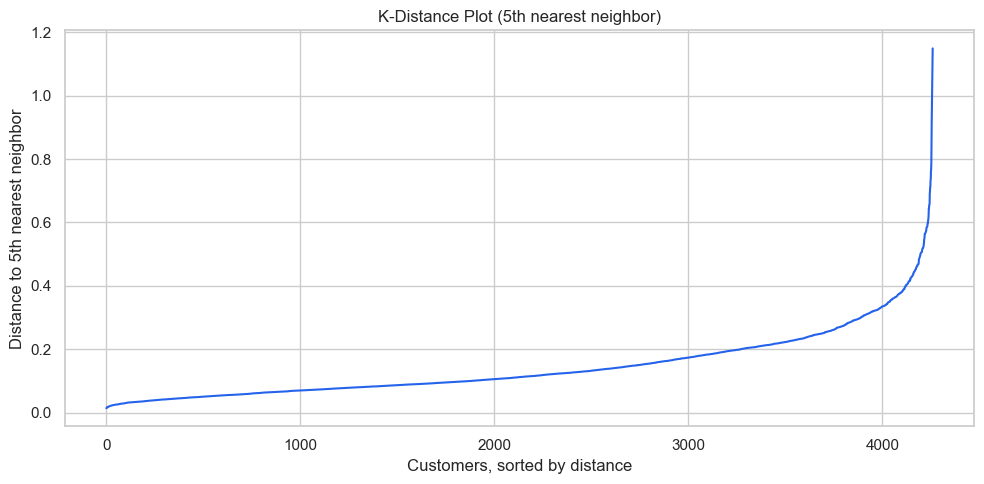

5th-NN distance percentiles (90/95/99): [0.285 0.356 0.551]


In [15]:
nn = NearestNeighbors(n_neighbors=5).fit(X_core_scaled)
distances, _ = nn.kneighbors(X_core_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color="#2563EB")
plt.title("K-Distance Plot (5th nearest neighbor)")
plt.xlabel("Customers, sorted by distance")
plt.ylabel("Distance to 5th nearest neighbor")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dbscan_k_distance.png", dpi=150, bbox_inches="tight")
plt.show()

print("5th-NN distance percentiles (90/95/99):",
      np.round(np.percentile(k_distances, [90, 95, 99]), 3))

In [16]:
dbscan_results = []
for eps in [0.2, 0.3, 0.4, 0.5, 0.6]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_core_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).mean() * 100
    sil = silhouette_score(X_core_scaled, labels) if n_clusters > 1 else np.nan
    dbscan_results.append({
        "eps": eps, "n_clusters": n_clusters, "noise_pct": round(noise_pct, 1), "silhouette": sil
    })

dbscan_results = pd.DataFrame(dbscan_results)
dbscan_results

,eps,n_clusters,noise_pct,silhouette
0,0.20,44,16.30,-0.15
1,0.30,14,4.90,-0.01
2,0.40,3,1.30,0.16
3,0.50,2,0.50,0.26
4,0.60,2,0.20,0.29


DBSCAN struggles here. At tight `eps` values it fragments the data into a large number of tiny clusters plus a lot of "noise" points; at looser values it mostly collapses into 2-3 clusters with a meaningfully worse silhouette than K-Means or hierarchical achieve at a comparable k. This isn't surprising — RFM segments in retail data tend to form overlapping density gradients ("more recent, more frequent, more spend") rather than clusters separated by clear empty regions, which is exactly the situation where density-based clustering underperforms partition-based methods.

## 11. Model comparison and final choice

| Method | Best interpretable k | Silhouette | Notes |
|---|---|---|---|
| K-Means | 4 | ~0.33 | Clean, stable, scales well, centroids are easy to explain to a client |
| Hierarchical (Ward) | 3–4 | ~0.30–0.33 | Very similar structure to K-Means, dendrogram confirms ~4 natural groupings |
| DBSCAN | n/a | worse across all tested `eps` | No clean density gap between segments; not a good fit for this feature space |

**Decision: K-Means with k=4.** It matches hierarchical clustering's structure (so the segmentation isn't an artifact of one algorithm's assumptions), comfortably outperforms DBSCAN, and produces four segments that map cleanly onto recognizable, actionable customer types once profiled below.

## 12. Fitting the final model

In [17]:
FINAL_K = 4

final_kmeans = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
core["Cluster"] = final_kmeans.fit_predict(X_core_scaled)

print(f"Final silhouette score (core customers, k={FINAL_K}): "
      f"{silhouette_score(X_core_scaled, core['Cluster']):.3f}")
core["Cluster"].value_counts().sort_index()

Final silhouette score (core customers, k=4): 0.335


Cluster
0     817
1     839
2    1429
3    1176
Name: count, dtype: int64

## 13. Profiling the clusters

Looking at the clusters on the **original, untransformed** RFM scale — this is what actually gets presented to the client, since "log1p(Monetary) of -0.4" means nothing to a marketing stakeholder.

In [18]:
profile = (
    core.groupby("Cluster")
    .agg(
        n_customers=("CustomerID", "count"),
        Recency_mean=("Recency", "mean"),
        Frequency_mean=("Frequency", "mean"),
        Monetary_mean=("Monetary", "mean"),
        Monetary_median=("Monetary", "median"),
    )
    .round(1)
)
profile["pct_of_core"] = (profile["n_customers"] / profile["n_customers"].sum() * 100).round(1)
profile.sort_values("Monetary_mean", ascending=False)

,n_customers,Recency_mean,Frequency_mean,Monetary_mean,Monetary_median,pct_of_core
Cluster,,,,,,
0,817,14.10,9.80,"3,907.60","2,883.10",19.20
3,1176,77.30,3.70,"1,464.60","1,160.10",27.60
1,839,21.80,1.90,456.40,391.70,19.70
2,1429,194.60,1.30,320.40,282.60,33.50


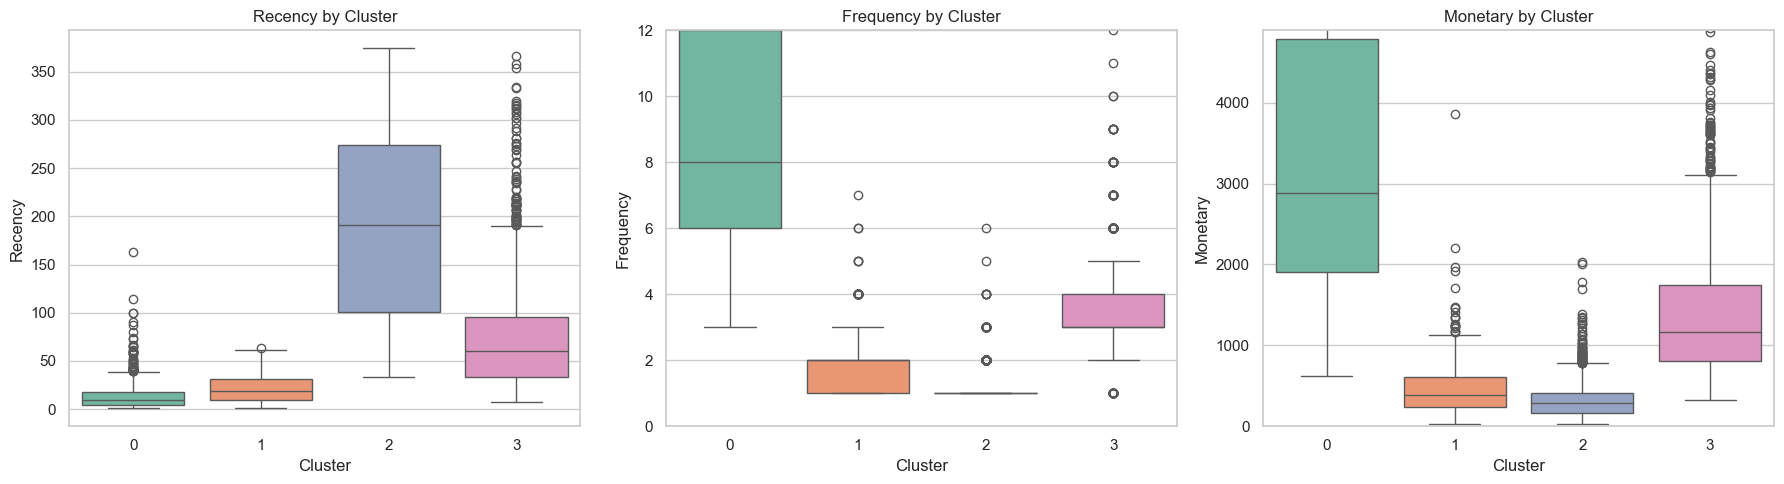

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=core, x="Cluster", y="Recency", ax=axes[0], palette="Set2")
axes[0].set_title("Recency by Cluster")
sns.boxplot(data=core, x="Cluster", y="Frequency", ax=axes[1], palette="Set2")
axes[1].set_title("Frequency by Cluster")
axes[1].set_ylim(0, core["Frequency"].quantile(0.95))
sns.boxplot(data=core, x="Cluster", y="Monetary", ax=axes[2], palette="Set2")
axes[2].set_title("Monetary by Cluster")
axes[2].set_ylim(0, core["Monetary"].quantile(0.95))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cluster_profiles_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Naming the segments

Translating the four numeric clusters into segment names a non-technical stakeholder can act on, based on the recency/frequency/monetary profile of each:

- **Recent, frequent, high spend → "Champions"** — the most valuable, most engaged customers. Retention and loyalty perks matter most here.
- **Moderate recency, moderate frequency, solid spend → "Loyal Customers"** — a reliable core base that buys regularly but isn't (yet) top-tier.
- **Recent but low frequency/spend → "New / Promising"** — customers who bought recently but haven't built up history yet; a nurture/onboarding target.
- **Long time since last purchase, low frequency/spend → "At Risk / Hibernating"** — the largest group by count; win-back campaigns are the priority.

The exact cluster-number-to-label mapping is derived below from the actual profile table rather than hardcoded, so this stays correct if the notebook is re-run and cluster numbering shifts.

In [20]:
ranked = profile.sort_values("Monetary_mean", ascending=False)
recency_rank = profile["Recency_mean"].rank()

segment_names = {}
sorted_by_value = ranked.index.tolist()

# Champions: highest monetary + lowest recency among the top-value clusters
champions = profile.sort_values(["Monetary_mean", "Recency_mean"], ascending=[False, True]).index[0]
segment_names[champions] = "Champions"

remaining = [c for c in profile.index if c not in segment_names]
at_risk = profile.loc[remaining, "Recency_mean"].idxmax()
segment_names[at_risk] = "At Risk / Hibernating"

remaining = [c for c in profile.index if c not in segment_names]
loyal = profile.loc[remaining, "Monetary_mean"].idxmax()
segment_names[loyal] = "Loyal Customers"

remaining = [c for c in profile.index if c not in segment_names]
segment_names[remaining[0]] = "New / Promising"

print(segment_names)
profile["Segment"] = profile.index.map(segment_names)
profile.sort_values("Monetary_mean", ascending=False)

{np.int32(0): 'Champions', np.int32(2): 'At Risk / Hibernating', np.int32(3): 'Loyal Customers', 1: 'New / Promising'}


,n_customers,Recency_mean,Frequency_mean,Monetary_mean,Monetary_median,pct_of_core,Segment
Cluster,,,,,,,
0,817,14.10,9.80,"3,907.60","2,883.10",19.20,Champions
3,1176,77.30,3.70,"1,464.60","1,160.10",27.60,Loyal Customers
1,839,21.80,1.90,456.40,391.70,19.70,New / Promising
2,1429,194.60,1.30,320.40,282.60,33.50,At Risk / Hibernating


In [21]:
core["Segment"] = core["Cluster"].map(segment_names)
core["Segment"].value_counts()

Segment
At Risk / Hibernating    1429
Loyal Customers          1176
New / Promising           839
Champions                 817
Name: count, dtype: int64

## 15. Bringing the outlier customers back in

The customers set aside in Section 6 never went through `.fit_predict`, so they don't have a cluster label yet. Rather than force them into one of the four "normal" segments (which would just water down those segments' averages), they get their own explicit segment — this is itself useful client-facing information, since these are exactly the accounts worth handling with a dedicated account manager rather than mass-market campaigns.

In [22]:
outliers = outliers.copy()
outliers["Cluster"] = -1
outliers["Segment"] = "Outlier / Wholesale"

print(f"Outlier customers: {outliers.shape[0]}")
outliers[["CustomerID", "Recency", "Frequency", "Monetary", "Segment"]].sort_values(
    "Monetary", ascending=False
).head(10)

Outlier customers: 73


,CustomerID,Recency,Frequency,Monetary,Segment
1689,14646,2,72,"279,138.02",Outlier / Wholesale
4197,18102,1,60,"259,657.30",Outlier / Wholesale
3725,17450,8,46,"194,390.79",Outlier / Wholesale
3006,16446,1,2,"168,472.50",Outlier / Wholesale
1879,14911,1,198,"136,161.83",Outlier / Wholesale
55,12415,24,20,"124,564.53",Outlier / Wholesale
1333,14156,10,54,"116,560.08",Outlier / Wholesale
3768,17511,3,31,"91,062.38",Outlier / Wholesale
0,12346,326,1,"77,183.60",Outlier / Wholesale
2700,16029,39,62,"72,708.09",Outlier / Wholesale


In [23]:
final_cols = ["CustomerID", "Recency", "Frequency", "Monetary", "Cluster", "Segment"]
customer_segments = pd.concat([core[final_cols], outliers[final_cols]], ignore_index=True)

assert customer_segments["CustomerID"].nunique() == rfm["CustomerID"].nunique(), \
    "Every customer from the RFM table should appear exactly once in the final output."
assert customer_segments["Segment"].isna().sum() == 0, "Every customer must have a segment."

print(f"Total customers segmented: {customer_segments.shape[0]:,}")
customer_segments["Segment"].value_counts()

Total customers segmented: 4,334


Segment
At Risk / Hibernating    1429
Loyal Customers          1176
New / Promising           839
Champions                 817
Outlier / Wholesale        73
Name: count, dtype: int64

In [24]:
segment_summary = (
    customer_segments.groupby("Segment")
    .agg(
        n_customers=("CustomerID", "count"),
        Recency_mean=("Recency", "mean"),
        Frequency_mean=("Frequency", "mean"),
        Monetary_mean=("Monetary", "mean"),
        Monetary_total=("Monetary", "sum"),
    )
    .round(1)
)
segment_summary["pct_of_customers"] = (segment_summary["n_customers"] / segment_summary["n_customers"].sum() * 100).round(1)
segment_summary["pct_of_revenue"] = (segment_summary["Monetary_total"] / segment_summary["Monetary_total"].sum() * 100).round(1)
segment_summary.sort_values("Monetary_total", ascending=False)

,n_customers,Recency_mean,Frequency_mean,Monetary_mean,Monetary_total,pct_of_customers,pct_of_revenue
Segment,,,,,,,
Champions,817,14.10,9.80,"3,907.60","3,192,515.40",18.90,36.50
Outlier / Wholesale,73,41.20,37.10,"40,841.70","2,981,441.50",1.70,34.10
Loyal Customers,1176,77.30,3.70,"1,464.60","1,722,424.50",27.10,19.70
At Risk / Hibernating,1429,194.60,1.30,320.40,"457,894.50",33.00,5.20
New / Promising,839,21.80,1.90,456.40,"382,951.80",19.40,4.40


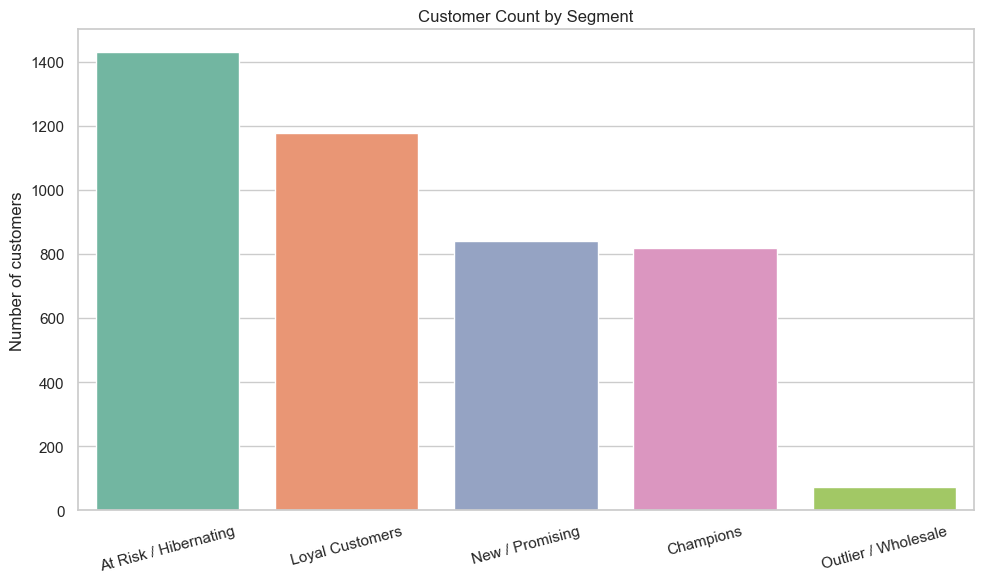

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
segment_order = segment_summary.sort_values("n_customers", ascending=False).index
sns.barplot(
    data=customer_segments,
    x="Segment",
    order=segment_order,
    y=customer_segments.groupby("Segment")["CustomerID"].transform("count"),
    ax=ax,
    palette="Set2",
    errorbar=None,
)
ax.set_title("Customer Count by Segment")
ax.set_ylabel("Number of customers")
ax.set_xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segment_customer_counts.png", dpi=150, bbox_inches="tight")
plt.show()

A small number of customers (the Outlier / Wholesale segment) contribute a disproportionate share of revenue relative to their headcount — consistent with what the EDA flagged early on. That's a useful client talking point on its own: revenue concentration risk sits with a handful of accounts, not just "big spenders" within the Champions segment.

## 16. Saving deliverables

Saving the fitted scaler and K-Means model together (so the exact preprocessing pipeline can be reapplied to new customers later), plus the final labeled customer-segment dataset.

In [26]:
with open(MODELS_DIR / "rfm_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(MODELS_DIR / "kmeans_model.pkl", "wb") as f:
    pickle.dump(final_kmeans, f)

with open(MODELS_DIR / "segment_pipeline.pkl", "wb") as f:
    pickle.dump({
        "scaler": scaler,
        "kmeans": final_kmeans,
        "feature_cols": feature_cols,
        "cluster_to_segment": segment_names,
        "outlier_bounds_note": "1.5x IQR on log1p(Recency/Frequency/Monetary); see notebook Section 6",
    }, f)

print(f"Saved scaler to {MODELS_DIR / 'rfm_scaler.pkl'}")
print(f"Saved model to  {MODELS_DIR / 'kmeans_model.pkl'}")
print(f"Saved full pipeline dict to {MODELS_DIR / 'segment_pipeline.pkl'}")

Saved scaler to ..\models\rfm_scaler.pkl
Saved model to  ..\models\kmeans_model.pkl
Saved full pipeline dict to ..\models\segment_pipeline.pkl


In [27]:
output_path = PROCESSED_DIR / "customer_segments.csv"
customer_segments.to_csv(output_path, index=False)
print(f"Saved final segments to {output_path}")
customer_segments.head()

Saved final segments to ..\data\processed\customer_segments.csv


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12347,2,7,"4,310.00",0,Champions
1,12348,75,4,"1,437.24",3,Loyal Customers
2,12349,19,1,"1,457.55",1,New / Promising
3,12350,310,1,294.40,2,At Risk / Hibernating
4,12352,36,7,"1,385.74",3,Loyal Customers


## Modelling conclusion

1. RFM features were engineered at the customer level from the same cleaned transaction data used in the EDA (4,334 customers, non-product stock codes excluded).
2. Recency, Frequency, and Monetary were all heavily right-skewed; `log1p` transformation brought all three within a reasonable range for distance-based clustering, and `StandardScaler` put them on a comparable scale.
3. A small set of extreme outliers (~1.7% of customers, wholesale-style buyers) was set aside before fitting so it couldn't distort the "normal" segments, then reintroduced afterward as its own explicit segment.
4. K-Means, Hierarchical (Ward), and DBSCAN were compared using the elbow method, silhouette score, and Davies-Bouldin index. DBSCAN underperformed the other two methods on this feature space. K-Means and hierarchical clustering agreed on roughly the same structure.
5. **K-Means with k=4** was chosen as the final model — not the silhouette-optimal k=2, per the client's guidance that cluster meaning matters more than statistical optimality. The four resulting segments — **Champions, Loyal Customers, New/Promising, and At Risk/Hibernating** — plus the separate **Outlier/Wholesale** group are each distinguishable and actionable from a marketing standpoint.
6. Every one of the 4,334 customers received a final segment label. Outputs (`customer_segments.csv`, the fitted scaler, and the K-Means model) are saved for the next phase of the project.

Handing this off to Elvis and Mary for the Evaluation phase — segment stability checks and translating these groups into business recommendations — and to me again downstream for the final Insights & Reporting writeup.